# Customer Retention Analysis for a Canadian E-Commerce Retailer

## Business Problem

The company wants to understand customer purchasing behavior, identify customers at risk of churn, and improve customer lifetime value (CLV).

For this project, a churned customer is defined as a customer who has not made a purchase in the last 90 days relative to the latest transaction date.

## Objectives

- Calculate key business KPIs.
- Measure customer retention and churn.
- Identify high-value customers.
- Analyze revenue by province and category.
- Recommend strategies to improve customer retention.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Show all columns (prevents pandas from hiding columns)
pd.set_option("display.max_columns", None)

In [8]:
df=pd.read_csv("Basket_IQ.csv")

In [5]:
df.head(10)

,InvoiceNo,InvoiceDate,CustomerID,City,Province,Country,Description,Category,Quantity,UnitPrice_CAD
0,10001,2024-04-23,CUST00001,Kitchener,ON,Canada,Car Phone Mount Magnetic Dashboard,Automotive,1,20.49
1,10002,2024-03-21,CUST00001,Kitchener,ON,Canada,Baby Monitor Video HD Wireless,Baby & Kids,1,130.62
2,10003,2024-02-16,CUST00001,Kitchener,ON,Canada,Protein Powder Vanilla 2kg,Health & Beauty,3,57.94
3,10004,2024-01-14,CUST00001,Kitchener,ON,Canada,Baby Monitor Video HD Wireless,Baby & Kids,1,113.37
4,10004,2024-01-14,CUST00001,Kitchener,ON,Canada,Yoga Pants Women High Waist,Clothing & Apparel,1,50.30
5,10004,2024-01-14,CUST00001,Kitchener,ON,Canada,LED Desk Lamp with USB Port,Electronics,1,27.77
6,10004,2024-01-14,CUST00001,Kitchener,ON,Canada,Instant Pot Duo 6 Quart,Home & Kitchen,3,138.42
7,10005,2023-12-11,CUST00001,Kitchener,ON,Canada,Mechanical Keyboard Wireless,Electronics,3,124.15
8,C10005,2023-12-11,CUST00001,Kitchener,ON,Canada,Hand Cream Set 3pc Canadian Maple,Health & Beauty,-1,17.87
9,10005,2023-12-11,CUST00001,Kitchener,ON,Canada,Air Fryer 5.8L Digital,Home & Kitchen,1,138.96


In [6]:
df.tail(10)

,InvoiceNo,InvoiceDate,CustomerID,City,Province,Country,Description,Category,Quantity,UnitPrice_CAD
102827,51143,2024-01-14,CUST05000,Kelowna,BC,Canada,Flannel Shirt Men Plaid,Clothing & Apparel,1,82.81
102828,51143,2024-01-14,CUST05000,Kelowna,BC,Canada,Windshield Ice Scraper Heavy Duty,Automotive,2,24.28
102829,51144,2023-12-19,NaN,Kelowna,BC,Canada,Hand Cream Set 3pc Canadian Maple,Health & Beauty,2,29.28
102830,51145,2023-11-23,CUST05000,Kelowna,BC,Canada,Ice Skates Youth Size,Sports & Outdoors,3,144.19
102831,51146,2023-10-28,CUST05000,Kelowna,BC,Canada,Protein Powder Vanilla 2kg,Health & Beauty,2,82.43
102832,51146,2023-10-28,CUST05000,Kelowna,BC,Canada,Running Shoes Men Lightweight,Clothing & Apparel,2,125.04
102833,51147,2023-10-02,CUST05000,Kelowna,BC,Canada,Ice Skates Youth Size,Sports & Outdoors,1,78.75
102834,51147,2023-10-02,CUST05000,Kelowna,BC,Canada,Vitamin D3 2000IU 365 Softgels,Health & Beauty,1,20.70
102835,51147,2023-10-02,CUST05000,Kelowna,BC,Canada,Webcam HD 1080p,Electronics,1,85.59
102836,51147,2023-10-02,CUST05000,Kelowna,BC,Canada,Snow Brush Extendable 50 inch,Automotive,3,25.82


# Initial Data Exploration (EDA)

In this section, we explore the dataset structure, identify missing values, check for duplicates, and understand the data types before cleaning and analysis.

In [9]:
df.shape

(102837, 10)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102837 entries, 0 to 102836
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   InvoiceNo      102837 non-null  object 
 1   InvoiceDate    102837 non-null  object 
 2   CustomerID     94732 non-null   object 
 3   City           102837 non-null  object 
 4   Province       102837 non-null  object 
 5   Country        102837 non-null  object 
 6   Description    102837 non-null  object 
 7   Category       102837 non-null  object 
 8   Quantity       102837 non-null  int64  
 9   UnitPrice_CAD  102837 non-null  float64
dtypes: float64(1), int64(1), object(8)
memory usage: 7.8+ MB


In [11]:
df.describe()

,Quantity,UnitPrice_CAD
count,102837.000000,102837.000000
mean,1.799469,79.017545
std,1.201461,55.747622
min,-3.000000,9.990000
25%,1.000000,35.230000
50%,2.000000,62.060000
75%,3.000000,110.770000
max,3.000000,349.910000


In [12]:
df.columns

Index(['InvoiceNo', 'InvoiceDate', 'CustomerID', 'City', 'Province', 'Country',
       'Description', 'Category', 'Quantity', 'UnitPrice_CAD'],
      dtype='object')

In [13]:
df.dtypes

,0
InvoiceNo,object
InvoiceDate,object
CustomerID,object
City,object
Province,object
Country,object
Description,object
Category,object
Quantity,int64
UnitPrice_CAD,float64


In [14]:
#checking null values
df.isnull().sum()

,0
InvoiceNo,0
InvoiceDate,0
CustomerID,8105
City,0
Province,0
Country,0
Description,0
Category,0
Quantity,0
UnitPrice_CAD,0


In [15]:
# finding the duplicates
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset; therefore, no duplicate removal was required.

In [16]:
df.isnull()

,InvoiceNo,InvoiceDate,CustomerID,City,Province,Country,Description,Category,Quantity,UnitPrice_CAD
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
102832,False,False,False,False,False,False,False,False,False,False
102833,False,False,False,False,False,False,False,False,False,False
102834,False,False,False,False,False,False,False,False,False,False
102835,False,False,False,False,False,False,False,False,False,False


In [17]:
# checking null in columns again
df.isnull().sum()

,0
InvoiceNo,0
InvoiceDate,0
CustomerID,8105
City,0
Province,0
Country,0
Description,0
Category,0
Quantity,0
UnitPrice_CAD,0


## Handling Missing Customer IDs

The dataset contained 8,105 transactions with missing customer IDs.

Since the objective of this project is customer retention analysis, these records were removed because customer behavior cannot be tracked without a unique identifier.

In [18]:
#removing customer ids which are null
df.dropna(subset=["CustomerID"], inplace=True)

In [19]:
df.isnull().sum()

,0
InvoiceNo,0
InvoiceDate,0
CustomerID,0
City,0
Province,0
Country,0
Description,0
Category,0
Quantity,0
UnitPrice_CAD,0


In [23]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [26]:
df.columns = df.columns.str.strip()
df.head(5)

,InvoiceNo,InvoiceDate,CustomerID,City,Province,Country,Description,Category,Quantity,UnitPrice_CAD
0,10001,2024-04-23,CUST00001,Kitchener,ON,Canada,Car Phone Mount Magnetic Dashboard,Automotive,1,20.49
1,10002,2024-03-21,CUST00001,Kitchener,ON,Canada,Baby Monitor Video HD Wireless,Baby & Kids,1,130.62
2,10003,2024-02-16,CUST00001,Kitchener,ON,Canada,Protein Powder Vanilla 2kg,Health & Beauty,3,57.94
3,10004,2024-01-14,CUST00001,Kitchener,ON,Canada,Baby Monitor Video HD Wireless,Baby & Kids,1,113.37
4,10004,2024-01-14,CUST00001,Kitchener,ON,Canada,Yoga Pants Women High Waist,Clothing & Apparel,1,50.30


In [36]:
# Check bad quantities
df[df["Quantity"] <= 0].shape

(4810, 12)

4,810 transactions have zero or negative quantities.


In [37]:
df[df["UnitPrice_CAD"] <= 0].shape

(0, 12)

No products have invalid prices.

In [32]:
# Create revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice_CAD"]

In [38]:
# Create month
df["Month"] = df["InvoiceDate"].dt.month

In [40]:
df = df[df["Quantity"] > 0]
df[df["Quantity"] <= 0].shape

(0, 12)

### Handling Invalid Quantities

The dataset contained 4,810 transactions with zero or negative quantities.

These records were removed because they likely represent returns, cancellations, or data-entry issues. Since the objective of this project is customer purchase behavior and retention analysis, only completed purchases with positive quantities were retained.

## Customer-Level Aggregation

Transactional data was aggregated to the customer level to understand purchasing behavior.

For each customer, we calculated:

- Total revenue generated
- Number of orders placed
- Total items purchased
- Most recent purchase date

This enables retention and churn analysis at the customer level.

In [43]:
# calculating a summary table for all transaction per customer
customer_summary = (
    df.groupby("CustomerID")
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Orders=("InvoiceNo", "nunique"),
          Total_Items=("Quantity", "sum"),
          Last_Purchase=("InvoiceDate", "max")
      )
      .reset_index()
)

customer_summary.head()
customer_summary.shape

(4958, 5)

This means we have 4958 unique customers.

In [46]:
customer_summary.head(5)

,CustomerID,Total_Revenue,Total_Orders,Total_Items,Last_Purchase
0,CUST00001,2150.04,7,28,2024-04-23
1,CUST00002,954.57,4,16,2024-03-29
2,CUST00003,414.96,1,6,2023-09-04
3,CUST00004,2018.82,6,28,2024-06-15
4,CUST00005,499.65,1,5,2024-03-31


In [48]:
#finding latest transaction dates
latest_date = df["InvoiceDate"].max()

print(latest_date)

2024-06-29 00:00:00


In [50]:
customer_summary["Days_Inactive"] = (
    latest_date - customer_summary["Last_Purchase"]
).dt.days

In [52]:
customer_summary.head()

,CustomerID,Total_Revenue,Total_Orders,Total_Items,Last_Purchase,Days_Inactive
0,CUST00001,2150.04,7,28,2024-04-23,67
1,CUST00002,954.57,4,16,2024-03-29,92
2,CUST00003,414.96,1,6,2023-09-04,299
3,CUST00004,2018.82,6,28,2024-06-15,14
4,CUST00005,499.65,1,5,2024-03-31,90


In [54]:
customer_summary["Customer_Status"] = np.where(
    customer_summary["Days_Inactive"] <= 30,
    "Active",
    np.where(
        customer_summary["Days_Inactive"] <= 90,
        "At Risk",
        "Churned"
    )
)

In [56]:
# providing customer_status

customer_summary["Customer_Status"].value_counts()

,count
Customer_Status,
Active,1751
Churned,1703
At Risk,1504


# Key Business Metrics (KPIs)

This section summarizes the company's performance and customer retention metrics.

In [72]:
# Total Revenue
total_revenue = df["Revenue"].sum()

print(total_revenue)

14222674.27


In [59]:
# Total Customers
total_customers = df["CustomerID"].nunique()

print(total_customers)

4958


In [61]:
#Total Orders
total_orders = df["InvoiceNo"].nunique()

print(total_orders)

39644


In [64]:
# finding average order value
aov = total_revenue / total_orders

print(aov)

358.7598191403491


In [66]:
# finding revenue per customer
revenue_per_customer = total_revenue / total_customers

print(revenue_per_customer)

2868.6313574021783


In [68]:
# Churn Rate
churn_rate = (
    customer_summary["Customer_Status"]
    .eq("Churned")
    .mean()
    * 100
)

print(churn_rate)

34.34852763210972


In [69]:
customer_summary["Customer_Status"].value_counts()

,count
Customer_Status,
Active,1751
Churned,1703
At Risk,1504


# Customer Retention Analysis

Customers were classified into three groups:

- Active: Purchased within the last 30 days.
- At Risk: No purchase for 31–90 days.
- Churned: No purchase for more than 90 days.

The analysis shows that approximately 34% of customers have churned, indicating opportunities for targeted retention and win-back campaigns.

## Q1: Who are the highest-value customers?

In [70]:
top_customers = (
    customer_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

top_customers

,CustomerID,Total_Revenue,Total_Orders,Total_Items,Last_Purchase,Days_Inactive,Customer_Status
3731,CUST03761,18025.15,38,204,2024-06-21,8,Active
4068,CUST04098,17656.17,40,198,2024-06-22,7,Active
3400,CUST03425,17514.48,38,202,2024-06-17,12,Active
615,CUST00621,17339.35,38,181,2024-06-03,26,Active
3068,CUST03089,17042.52,38,188,2024-06-27,2,Active
3444,CUST03470,16674.88,38,184,2024-06-04,25,Active
3408,CUST03433,16578.44,39,193,2024-06-09,20,Active
4639,CUST04678,16571.81,38,207,2024-06-15,14,Active
1714,CUST01726,16333.72,38,182,2024-06-26,3,Active
4605,CUST04644,16329.41,38,183,2024-06-27,2,Active


## Q2: Which provinces generate the highest revenue?

In [73]:
province_revenue = (
    df.groupby("Province")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

province_revenue.head(10)

,Province,Revenue
0,ON,5463935.24
1,BC,3023126.01
2,QC,2178899.67
3,AB,1940166.08
4,SK,447892.85
5,MB,414694.89
6,NS,301922.93
7,NB,257472.67
8,NL,194563.93


## Q3: Which product categories drive the most revenue?

In [74]:
category_revenue = (
    df.groupby("Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

category_revenue

,Category,Revenue
0,Sports & Outdoors,3134333.61
1,Clothing & Apparel,2782048.55
2,Home & Kitchen,2508020.23
3,Electronics,2377081.84
4,Baby & Kids,1498177.22
5,Health & Beauty,941866.03
6,Automotive,649751.22
7,Books & Stationery,331395.57


## Q4: How has revenue changed over time?

In [75]:
monthly_revenue = (
    df.groupby("Month")["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue.head()

,Month,Revenue
0,1,1428562.55
1,2,1248925.91
2,3,1512147.89
3,4,1484549.85
4,5,1426981.59


# Data Visualizations

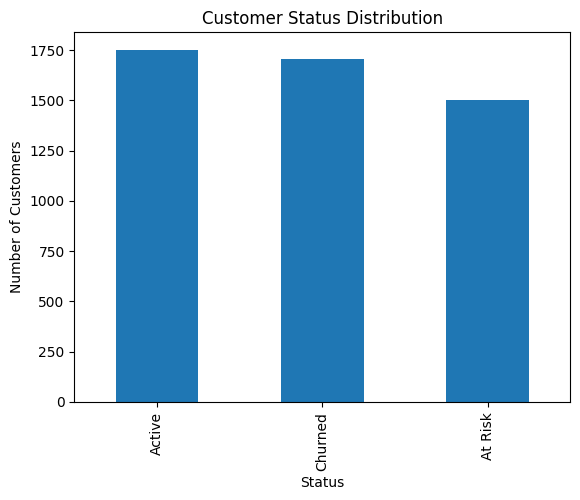

In [76]:
# customer status distribution

customer_summary["Customer_Status"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Customers")

plt.show()

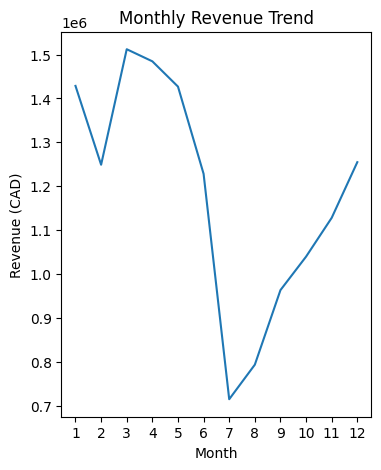

In [105]:
#Monthly Revenue Trend

plt.figure(figsize=(4,5))

plt.plot(
    monthly_revenue["Month"].astype(str),
    monthly_revenue["Revenue"]
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (CAD)")



plt.show()

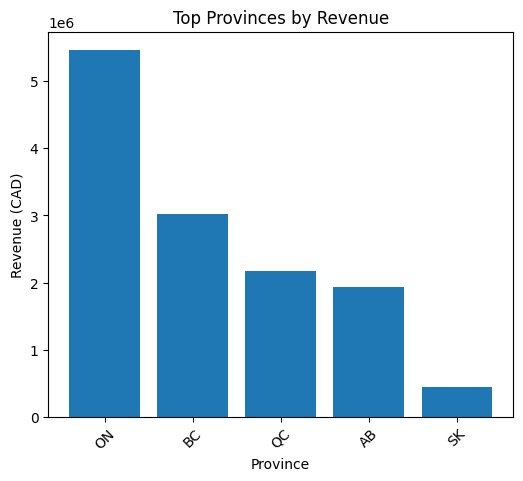

In [106]:
#Top 5 Provinces
top_provinces = province_revenue.head(5)

plt.figure(figsize=(6,5))

plt.bar(
    top_provinces["Province"],
    top_provinces["Revenue"]
)

plt.title("Top Provinces by Revenue")
plt.xlabel("Province")
plt.ylabel("Revenue (CAD)")

plt.xticks(rotation=45)

plt.show()

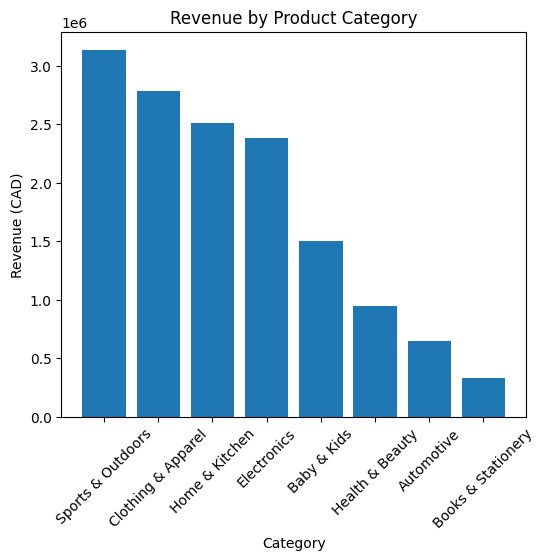

In [107]:
#Top Categories
plt.figure(figsize=(6,5))

plt.bar(
    category_revenue["Category"],
    category_revenue["Revenue"]
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (CAD)")
plt.xticks(rotation=45)

plt.show()

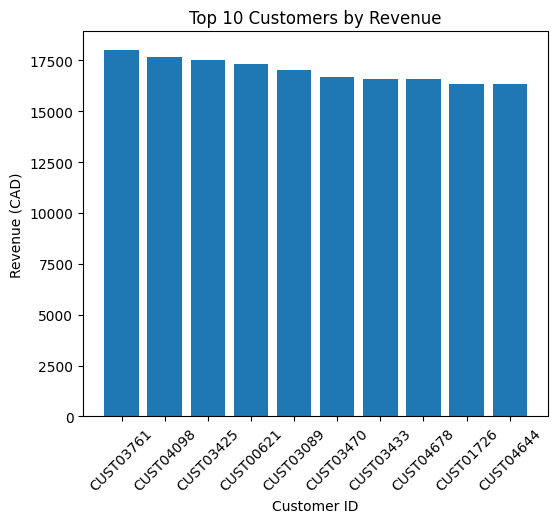

In [108]:
#Top Customers
plt.figure(figsize=(6,5))

plt.bar(
    top_customers["CustomerID"].astype(str),
    top_customers["Total_Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (CAD)")

plt.xticks(rotation=45)

plt.show()

In [99]:
top_customers.head()


,CustomerID,Total_Revenue,Total_Orders,Total_Items,Last_Purchase,Days_Inactive,Customer_Status
3731,CUST03761,18025.15,38,204,2024-06-21,8,Active
4068,CUST04098,17656.17,40,198,2024-06-22,7,Active
3400,CUST03425,17514.48,38,202,2024-06-17,12,Active
615,CUST00621,17339.35,38,181,2024-06-03,26,Active
3068,CUST03089,17042.52,38,188,2024-06-27,2,Active


In [101]:
province_revenue.head()

,Province,Revenue
0,ON,5463935.24
1,BC,3023126.01
2,QC,2178899.67
3,AB,1940166.08
4,SK,447892.85


In [102]:
category_revenue.head()

,Category,Revenue
0,Sports & Outdoors,3134333.61
1,Clothing & Apparel,2782048.55
2,Home & Kitchen,2508020.23
3,Electronics,2377081.84
4,Baby & Kids,1498177.22


# Executive Summary

## Business Overview

This project analyzed customer purchasing behavior for a Canadian e-commerce retailer using transactional data.

Customers were categorized as Active, At Risk, or Churned based on a 90-day inactivity rule.

## Key Metrics

- Total Customers: 4,958
- Churn Rate: 34.35%
- Active Customers: 1,751
- At-Risk Customers: 1,504
- Churned Customers: 1,703

## Top Province

Ontario generated the highest revenue, contributing significantly more than other provinces.

## Top Product Category

Sports & Outdoors was the highest-performing category by revenue.

# Key Findings

### 1. Customer churn remains significant

Approximately 34% of customers have churned, suggesting opportunities for retention and re-engagement strategies.

### 2. Repeat customers generate substantial value

The highest-value customers placed nearly 40 orders each, demonstrating the importance of customer loyalty.

### 3. Ontario is the dominant market

Ontario generated over CAD 5.4 million in revenue, making it the company's strongest region.

### 4. Sports & Outdoors leads sales

Sports & Outdoors products generated the highest revenue, followed by Clothing & Apparel and Home & Kitchen.

### 5. A large at-risk segment exists

More than 1,500 customers have not purchased within the last 31–90 days and should be targeted before they churn.

# Business Recommendations

### Recommendation 1: Launch win-back campaigns

Target the 1,703 churned customers with personalized promotions and discount offers to encourage repeat purchases.

### Recommendation 2: Protect at-risk customers

Implement automated email campaigns for customers inactive for 31–90 days before they become fully churned.

### Recommendation 3: Strengthen loyalty programs

Reward high-value customers through VIP programs, exclusive discounts, and early access to new products.

### Recommendation 4: Prioritize Ontario, British Columbia, and Quebec

Allocate marketing resources toward provinces generating the highest revenue while exploring growth opportunities in smaller markets.

### Recommendation 5: Expand high-performing categories

Increase investment in Sports & Outdoors and Clothing & Apparel products to capitalize on strong customer demand.